In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
try:
    df = pd.read_csv('Sample - Superstore.csv', encoding='ISO-8859-1')
except:
    df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

df = df.dropna(subset=['Sales', 'Quantity', 'Discount', 'Product ID'])
q_limit = df['Sales'].quantile(0.99)
df = df[df['Sales'] < q_limit]

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, format='mixed')
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Sales_Log'] = np.log1p(df['Sales'])

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

product_means = train_df.groupby('Product ID')['Sales_Log'].mean()

train_df['Prod_Avg_Sales'] = train_df['Product ID'].map(product_means)
test_df['Prod_Avg_Sales'] = test_df['Product ID'].map(product_means)

global_mean = train_df['Sales_Log'].mean()
train_df['Prod_Avg_Sales'] = train_df['Prod_Avg_Sales'].fillna(global_mean)
test_df['Prod_Avg_Sales'] = test_df['Prod_Avg_Sales'].fillna(global_mean)

categorical_features = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
numeric_features = ['Quantity', 'Discount', 'Order Month', 'Order Year', 'Prod_Avg_Sales']

X_train = train_df[categorical_features + numeric_features]
y_train = train_df['Sales_Log']
X_test = test_df[categorical_features + numeric_features]
y_test = test_df['Sales_Log']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ))
])

print("Обучение")
model.fit(X_train, y_train)

Обучение


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Quantity', 'Discount',
                                                   'Order Month', 'Order Year',
                                                   'Prod_Avg_Sales']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Ship Mode', 'Segment',
                                                   'Region', 'Category',
                                                   'Sub-Category'])])),
                ('regressor',
                 GradientBoostingRegressor(max_depth=5, n_estimators=300,
                                           random_state=42))])


Метрики
MAE: 53.36
RMSE: 148.02
R²: 0.8083


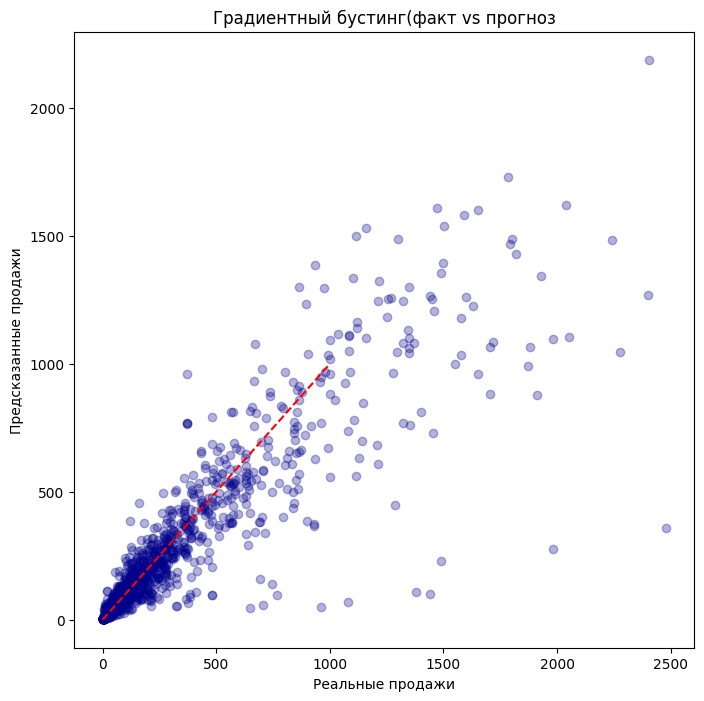

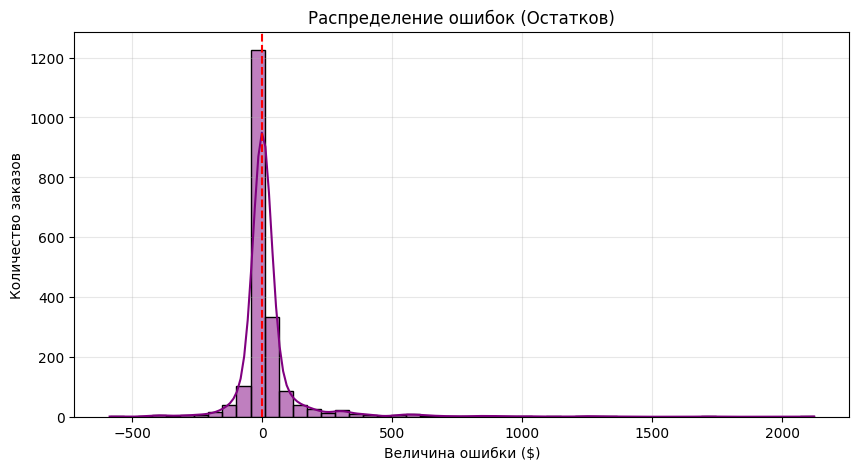

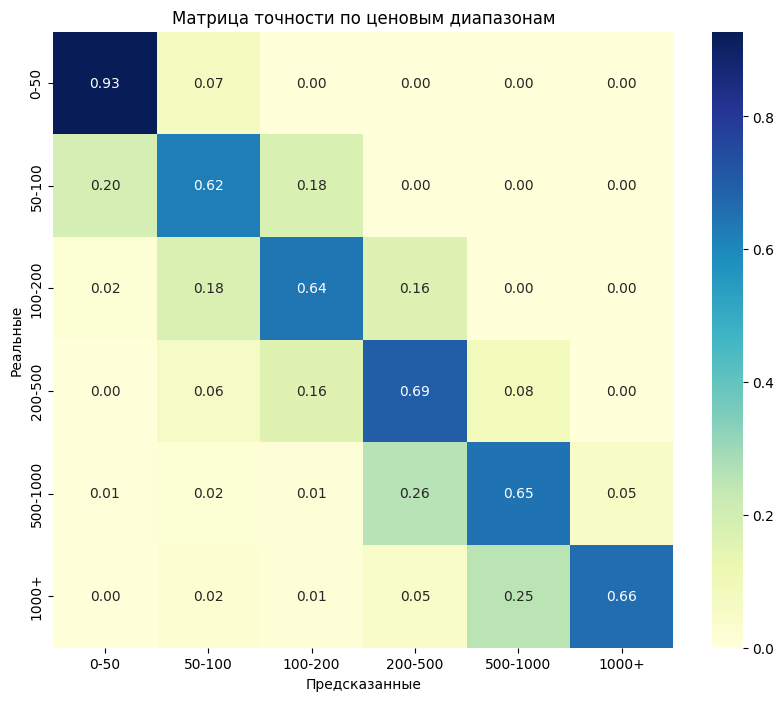

/tmp/ipykernel_620/477728390.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


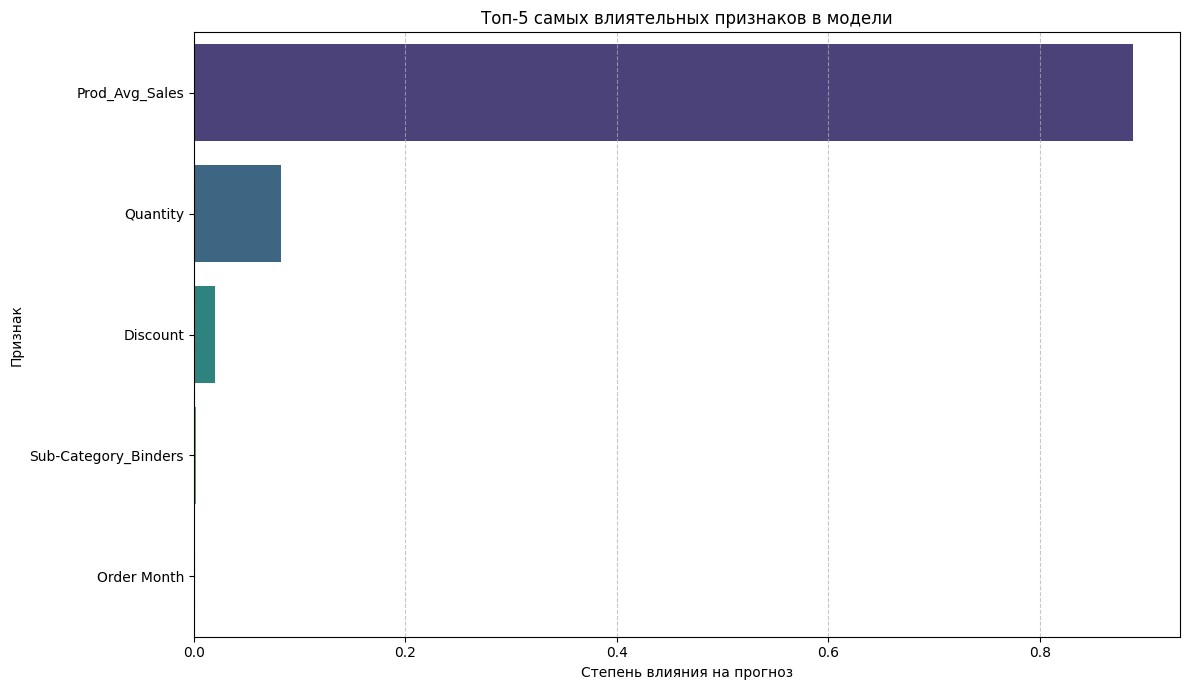


Топ-5 признаков по важности:
                 Feature  Importance
4         Prod_Avg_Sales    0.888206
0               Quantity    0.082482
1               Discount    0.019860
22  Sub-Category_Binders    0.002266
2            Order Month    0.000865


In [ ]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print(f"\nМетрики")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test_real, y_pred, alpha=0.3, color='darkblue')
plt.plot([0, 1000], [0, 1000], 'r--')
plt.xlabel("Реальные продажи")
plt.ylabel("Предсказанные продажи")
plt.title("Градиентный бустинг(факт vs прогноз")
plt.show()

residuals = y_test_real - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Распределение ошибок (Остатков)")
plt.xlabel("Величина ошибки ($)")
plt.ylabel("Количество заказов")
plt.grid(True, alpha=0.3)
plt.show()

bins = [0, 50, 100, 200, 500, 1000, np.inf]
labels = ['0-50', '50-100', '100-200', '200-500', '500-1000', '1000+']

actual_binned = pd.cut(y_test_real, bins=bins, labels=labels)
pred_binned = pd.cut(y_pred, bins=bins, labels=labels)

error_matrix = pd.crosstab(actual_binned, pred_binned,
                           rownames=['Реальные'],
                           colnames=['Предсказанные'],
                           normalize='index')

plt.figure(figsize=(10, 8))
sns.heatmap(error_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Матрица точности по ценовым диапазонам")
plt.show()

regressor = model.named_steps['regressor']

ohe = model.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(ohe_feature_names)

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': regressor.feature_importances_
})

top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title("Топ-5 самых влиятельных признаков в модели")
plt.xlabel("Степень влияния на прогноз")
plt.ylabel("Признак")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nТоп-5 признаков по важности:")
print(top_features.head(5))